# AIR CONCENTRATION <hr style = "border:2.5px solid #0000FF"></hr>

<b> Jehan Jedd Chavez </b>
<br> Comptech Student T09

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [2]:
df = pd.read_csv(r"dataset/station_day.csv",
                 delimiter=",")
df

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2
0,165.32,144.61,25.53,42.48,79.30,25.09,2.03,11.53
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,175.95,135.85,28.43,38.51,56.13,22.04,1.10,14.32
3,190.22,147.27,33.75,NaN,66.36,NaN,1.97,NaN
4,172.92,157.59,30.63,44.00,65.54,16.95,1.56,10.95
...,...,...,...,...,...,...,...,...
945,185.21,139.68,24.22,54.25,72.11,23.19,1.56,7.23
946,178.55,130.97,31.06,43.50,55.70,12.34,1.49,13.07
947,183.21,153.79,20.50,46.22,71.26,20.88,1.56,9.55
948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.dropna()

print(f"Total rows after cleaning: {len(df)}")

Total rows after cleaning: 683


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 0 to 947
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   683 non-null    float64
 1   PM10    683 non-null    float64
 2   NO      683 non-null    float64
 3   NO2     683 non-null    float64
 4   NOx     683 non-null    float64
 5   NH3     683 non-null    float64
 6   CO      683 non-null    float64
 7   SO2     683 non-null    float64
dtypes: float64(8)
memory usage: 48.0 KB


In [5]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,179.840000,141.888389,25.076896,39.843001,64.554758,19.753309,1.498331,11.910820
std,14.580012,14.920820,4.833907,8.273303,12.485109,3.931185,0.295964,3.046576
min,142.240000,102.810000,9.900000,16.070000,29.850000,7.290000,0.680000,3.300000
25%,169.450000,131.540000,21.950000,34.255000,55.670000,17.355000,1.300000,9.845000
50%,179.820000,142.110000,25.030000,39.750000,64.350000,19.980000,1.490000,11.930000
75%,189.630000,151.245000,28.315000,45.350000,72.245000,22.510000,1.695000,13.980000
max,217.050000,179.030000,40.690000,71.410000,103.920000,31.020000,2.430000,20.780000


# Data Cleaning

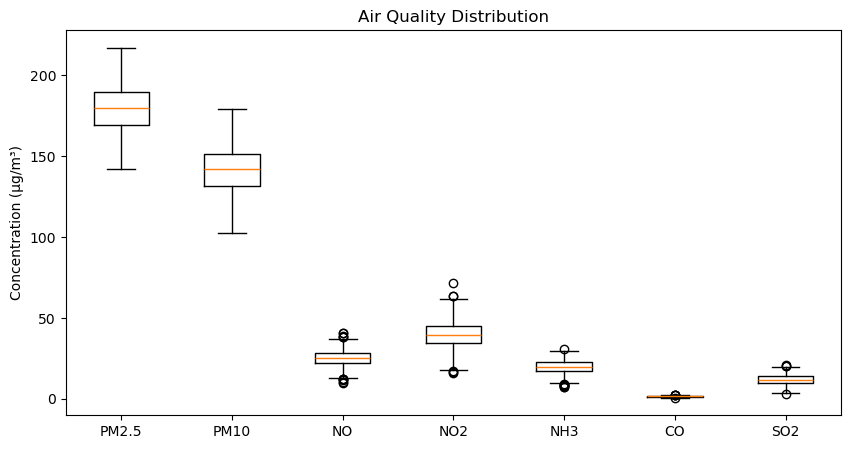

In [6]:
# check for outliers
plt.figure(figsize=(10,5))
plt.boxplot(df[['PM2.5','PM10','NO','NO2','NH3','CO','SO2']], 
            tick_labels=['PM2.5','PM10','NO','NO2','NH3','CO','SO2'])
plt.title('Air Quality Distribution')
plt.ylabel('Concentration (μg/m³)')
plt.show()

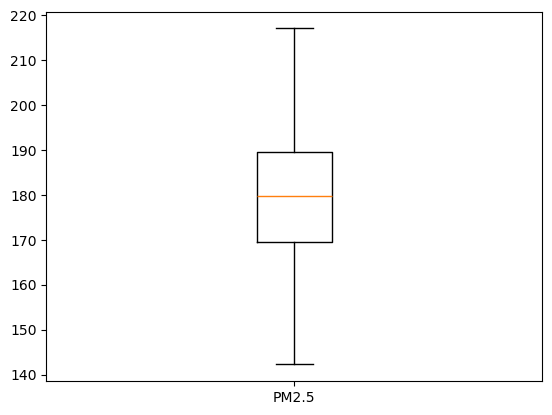

In [7]:
z_pm25 = stats.zscore(df['PM2.5'])
pm25_outliers = (z_pm25<-3)|(z_pm25>3)
df = df[~pm25_outliers]

plt.boxplot(df['PM2.5'],tick_labels=['PM2.5'])
plt.show()

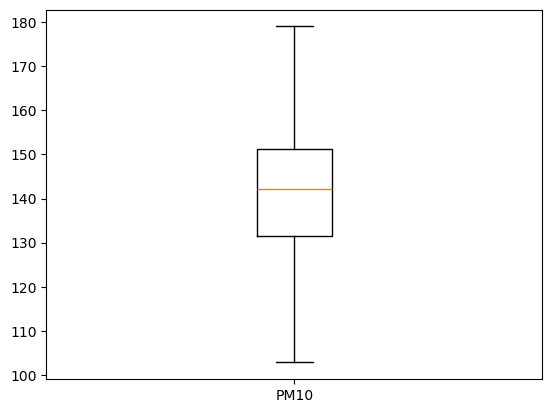

In [8]:
z_pm10 = stats.zscore(df['PM10'])
pm10_outliers = (z_pm10<-3)|(z_pm10>3)
df = df[~pm10_outliers]

plt.boxplot(df['PM10'],tick_labels=['PM10'])
plt.show()

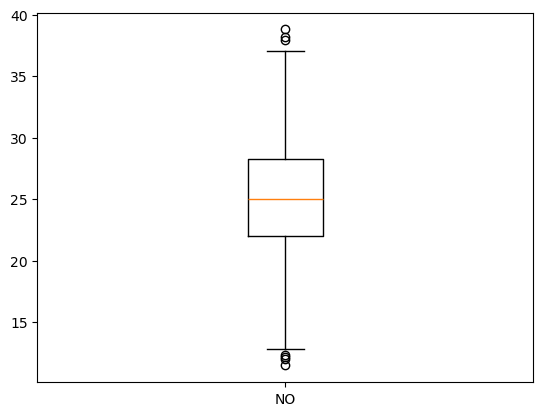

In [9]:
z_no = stats.zscore(df['NO'])
no_outliers = (z_no<-3)|(z_no>3)
df = df[~no_outliers]

plt.boxplot(df['NO'],tick_labels=['NO'])
plt.show()

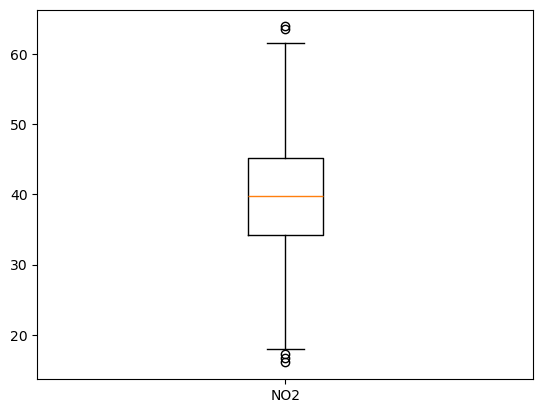

In [10]:
z_no2 = stats.zscore(df['NO2'])
no2_outliers = (z_no2<-3)|(z_no2>3)
df = df[~no2_outliers]

plt.boxplot(df['NO2'],tick_labels=['NO2'])
plt.show()

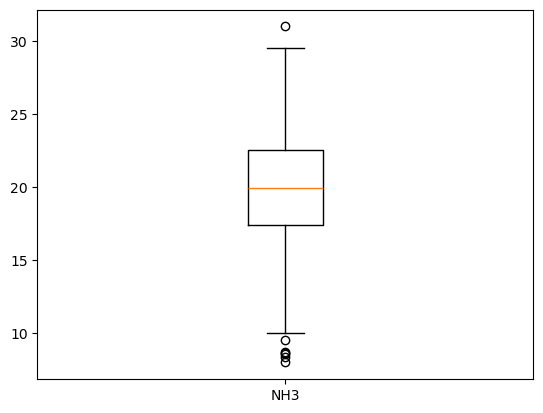

In [11]:
z_nh3 = stats.zscore(df['NH3'])
nh3_outliers = (z_nh3<-3)|(z_nh3>3)
df = df[~nh3_outliers]

plt.boxplot(df['NH3'],tick_labels=['NH3'])
plt.show()

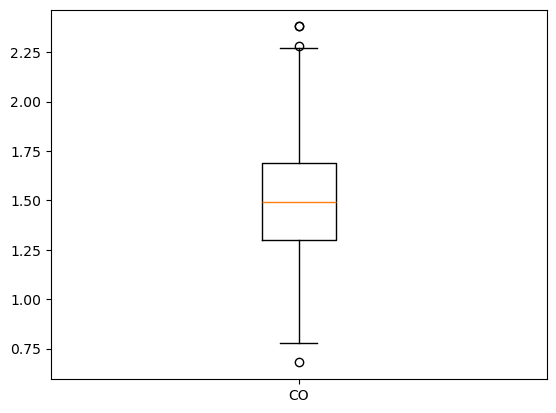

In [12]:
z_co = stats.zscore(df['CO'])
co_outliers = (z_co<-3)|(z_co>3)
df = df[~co_outliers]

plt.boxplot(df['CO'],tick_labels=['CO'])
plt.show()

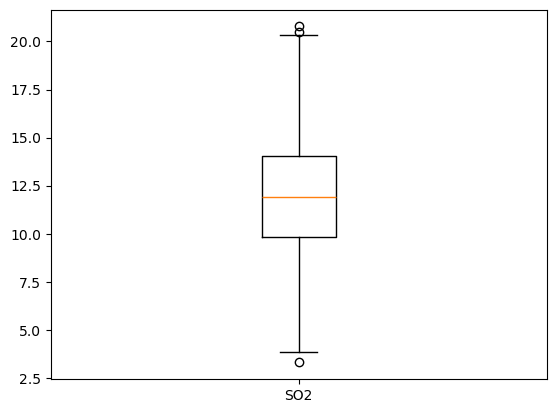

In [13]:
z_so2 = stats.zscore(df['SO2'])
so2_outliers = (z_so2<-3)|(z_so2>3)
df = df[~so2_outliers]

plt.boxplot(df['SO2'],tick_labels=['SO2'])
plt.show()

In [14]:
 #save cleaned dataset
df.to_csv(r"dataset\station_day_sample_cleaned.csv",
            index=False)

In [15]:
df = pd.read_csv(r"dataset/station_day_sample_cleaned.csv",
                 delimiter=",")
df

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2
0,165.32,144.61,25.53,42.48,79.30,25.09,2.03,11.53
1,175.95,135.85,28.43,38.51,56.13,22.04,1.10,14.32
2,172.92,157.59,30.63,44.00,65.54,16.95,1.56,10.95
3,165.21,120.03,24.62,47.97,75.30,23.49,1.76,9.49
4,212.86,148.55,25.62,39.95,63.81,22.08,1.09,7.12
...,...,...,...,...,...,...,...,...
669,168.77,143.51,26.31,42.64,77.69,16.35,1.25,16.65
670,181.71,158.40,27.04,32.38,40.22,25.28,1.83,7.68
671,185.21,139.68,24.22,54.25,72.11,23.19,1.56,7.23
672,178.55,130.97,31.06,43.50,55.70,12.34,1.49,13.07


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   674 non-null    float64
 1   PM10    674 non-null    float64
 2   NO      674 non-null    float64
 3   NO2     674 non-null    float64
 4   NOx     674 non-null    float64
 5   NH3     674 non-null    float64
 6   CO      674 non-null    float64
 7   SO2     674 non-null    float64
dtypes: float64(8)
memory usage: 42.3 KB


In [17]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2
count,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000
mean,179.792033,141.808309,25.088427,39.775653,64.513323,19.769214,1.494407,11.908145
std,14.582399,14.855126,4.701628,8.197702,12.437798,3.879626,0.292557,3.059697
min,142.240000,102.810000,11.480000,16.070000,29.850000,7.970000,0.680000,3.300000
25%,169.392500,131.540000,22.002500,34.252500,55.767500,17.342500,1.300000,9.825000
50%,179.850000,142.080000,25.030000,39.695000,64.380000,19.965000,1.490000,11.890000
75%,189.562500,151.042500,28.295000,45.210000,72.220000,22.510000,1.690000,14.042500
max,217.050000,179.030000,38.800000,63.880000,103.920000,31.020000,2.380000,20.780000


# 2 Sample t-Test 

In [18]:
df[['PM2.5','PM10']].describe()

,PM2.5,PM10
count,674.000000,674.000000
mean,179.792033,141.808309
std,14.582399,14.855126
min,142.240000,102.810000
25%,169.392500,131.540000
50%,179.850000,142.080000
75%,189.562500,151.042500
max,217.050000,179.030000


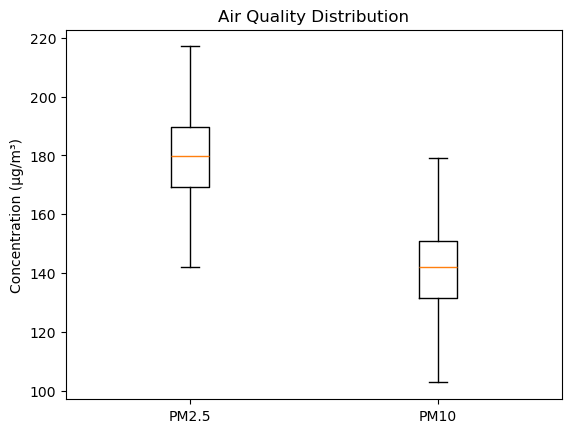

In [19]:
# check for outliers
plt.boxplot(df[['PM2.5','PM10']],tick_labels=['PM2.5','PM10'])
plt.title('Air Quality Distribution')
plt.ylabel('Concentration (μg/m³)')
plt.show()

In [20]:
# shapiro-wilk normality test
print("PM2.5:")
w_stat, p_value = stats.shapiro(df['PM2.5'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nPM10:")
w_stat, p_value = stats.shapiro(df['PM10'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

PM2.5:
w_stat: 0.9969
P-value: 0.2254
Normal data

PM10:
w_stat: 0.9966
P-value: 0.1677
Normal data


In [21]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_pm2.5 = var_pm10
Ha: var_pm2.5 != var_pm10
"""

var_pm25 = df['PM2.5'].var(ddof=1)
var_pm10 = df['PM10'].var(ddof=1)

# F-statistic
if var_pm25 > var_pm10:
    f_stat = var_pm25/var_pm10
else:
    f_stat = var_pm10/var_pm25

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_pm25 = df['PM2.5'].count()-1
dof_pm10 = df['PM10'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_pm25, dof_pm10)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 1.0378
p_value = 0.3154
equal variances


In [22]:
"""
Two-Sample T-test (Independent)
-------------------------------
Ho: Mean PM2.5 = Mean PM10
Ha: Mean PM2.5 != Mean PM10
"""

t_stat, p_value = stats.ttest_ind(df['PM2.5'], df['PM10'], 
                                  alternative='two-sided', 
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# Verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("The average concentration of PM2.5 is significantly higher than PM10.")
else:
    # fail to reject null hypothesis
    print("Fail to Reject Ho. The concentrations are statistically similar.")

t_stat = 47.3721
p_value = 0.0000
The average concentration of PM2.5 is significantly higher than PM10.


In [23]:
"""
left-tailed test
------------------
Ho: u_pm2.5 = u_pm10
Ha: u_pm2.5 > u_pm10
"""
    
# cohen's d
pm25_mean = df['PM2.5'].mean()
pm10_mean = df['PM10'].mean()
pm25_std = df['PM2.5'].std(ddof=1)

d = abs((pm25_mean - pm10_mean)/pm25_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['PM2.5'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 2.6048
Power of the test: 100.00%


# Paired t-Test

In [24]:
"""
Paired T-Test (Air Quality Concentration)
"""

t_stat_paired, p_val_paired = stats.ttest_rel(df['PM2.5'], df['PM10'])
print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

alpha = 0.05
if p_val_paired < alpha:
    # reject null hypothesis
    if df['PM2.5'].mean() > df['PM10'].mean(): 
        print(f"PM2.5 is significantly more concentrated in the air than PM10")
    else:
        print(f"PM10 is significantly more concentrated in the air than PM2.5")
     # fail to reject null hypothesis
else:
    print("There is no significant difference in concentration levels.")

t_stat = 47.3721
p_value = 0.0000
PM2.5 is significantly more concentrated in the air than PM10


# CONCLUSION

To evaluate the concentration levels of pollutants, both a two-sample t-test and a paired t-test were utilized. The two-sample t-test yielded a t-statistic of 47.3721 with a p-value < 0.0000, and paired t-test yielded a t-statistic of 47.3721 with a p-value<0.0000 also, confirming that the overall average concentration of PM2.5 is significantly higher than that of PM10.

However, the paired t-test is considered the most applicable method for this specific dataset. Because PM2.5 and PM10 are recorded simultaneously at the same monitoring station, they are naturally "paired" observations. While the two-sample test compares overall averages, the paired t-test accounts for the internal relationship between the pollutants, making the statistical conclusion more robust. At the 0.05 significance level, the null hypothesis is rejected. Nonetheless, the result reveals that PM2.5 concentrations are significantly higher than PM10 levels at this location.